# Crop Suitability Classification - Capstone Notebook
Run top-to-bottom from the `notebooks/` folder. Mirrors `src/` scripts so every result is reproducible.

In [2]:
import sys, os, glob, shutil, subprocess

REPO = 'https://github.com/Harischandra-Prasad-Vissamsetti/Crop-Suitability-Classification.git'

def find_root():
    p = os.getcwd()
    for _ in range(4):                       # this folder and up to 3 parent folders
        if os.path.exists(os.path.join(p, 'src', 'preprocessing.py')):
            return p
        p = os.path.dirname(p)
    hits = glob.glob(os.path.join(os.getcwd(), '**', 'src', 'preprocessing.py'), recursive=True)
    return os.path.dirname(os.path.dirname(hits[0])) if hits else None

root = find_root()
if root is None:                             # project not here: download it fresh
    shutil.rmtree('Crop-Suitability-Classification', ignore_errors=True)
    subprocess.run(['git', 'clone', REPO], check=True)
    root = os.path.abspath('Crop-Suitability-Classification')

os.chdir(root)
sys.path.insert(0, os.path.join(root, 'src'))

import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from preprocessing import *
pd.set_option('display.width', 140)
print('Working folder:', os.getcwd())
print('src files     :', os.listdir('src'))

Working folder: /content/Crop-Suitability-Classification
src files     : ['eda.py', '__pycache__', 'train.py', 'preprocessing.py']


## 1. Load & inspect

In [3]:
raw = pd.read_csv('data/crop_data.csv')
print(raw.shape); display(raw.head()); display(raw.describe().round(2))

(2200, 8)


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


,N,P,K,temperature,humidity,ph,rainfall
count,2200.00,2200.00,2200.00,2200.00,2200.00,2200.00,2200.00
mean,50.55,53.36,48.15,25.62,71.48,6.47,103.46
std,36.92,32.99,50.65,5.06,22.26,0.77,54.96
min,0.00,5.00,5.00,8.83,14.26,3.50,20.21
25%,21.00,28.00,20.00,22.77,60.26,5.97,64.55
50%,37.00,51.00,32.00,25.60,80.47,6.43,94.87
75%,84.25,68.00,49.00,28.56,89.95,6.92,124.27
max,140.00,145.00,205.00,43.68,99.98,9.94,298.56


## 2. Data quality: missing values, duplicates, impossible values

In [4]:
print('duplicates:', raw.duplicated().sum())
print(raw.isna().sum())
print({c:int(((raw[c]<lo)|(raw[c]>hi)).sum()) for c,(lo,hi) in VALID_RANGES.items()})

duplicates: 0
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64
{'N': 0, 'P': 0, 'K': 0, 'temperature': 0, 'humidity': 0, 'ph': 0, 'rainfall': 0}


In [5]:
df = clean(raw); print(df.shape); df[TARGET].value_counts().describe()

(2200, 8)


,count
count,22.0
mean,100.0
std,0.0
min,100.0
25%,100.0
50%,100.0
75%,100.0
max,100.0


## 3. EDA

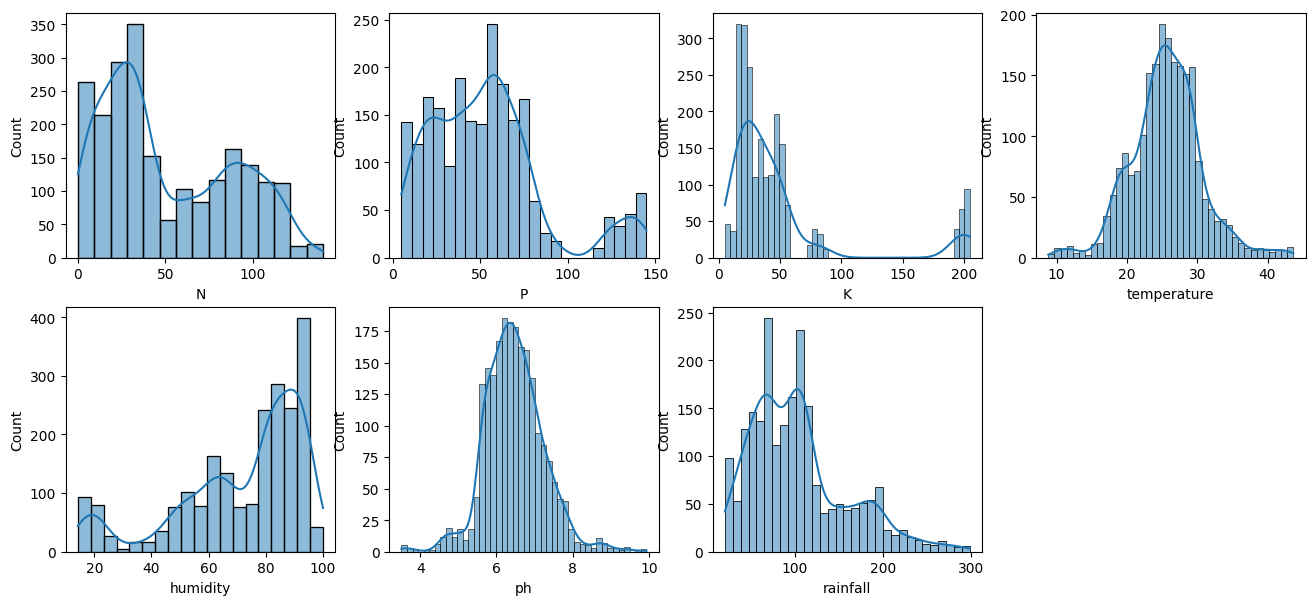

In [6]:
fig,ax=plt.subplots(2,4,figsize=(16,7))
for a,c in zip(ax.ravel(),FEATURES): sns.histplot(df[c],kde=True,ax=a)
ax.ravel()[-1].axis('off'); plt.show()

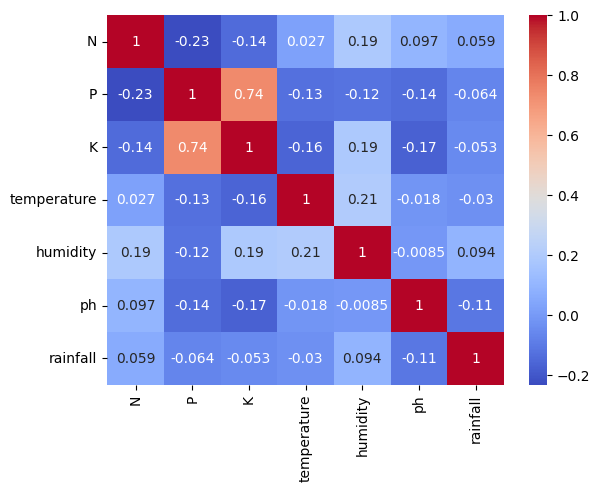

In [7]:
sns.heatmap(df[FEATURES].corr(),annot=True,cmap='coolwarm'); plt.show()

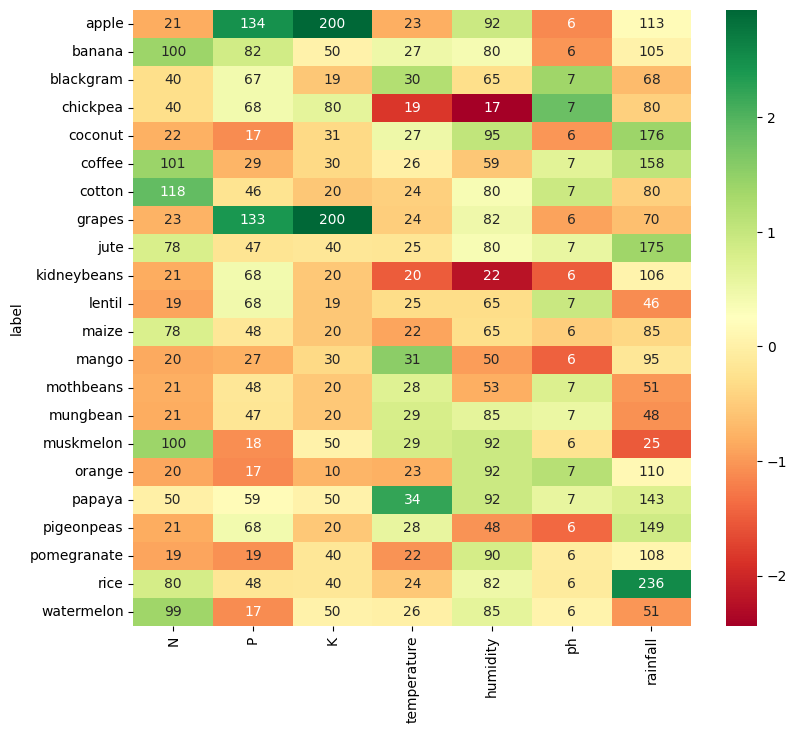

In [8]:
m=df.groupby(TARGET)[FEATURES].mean(); sns.heatmap((m-m.mean())/m.std(),cmap='RdYlGn',annot=m.round(0),fmt='g'); plt.gcf().set_size_inches(9,8); plt.show()

## 4. Split first (avoid leakage), then model
Imputer + scaler live **inside** the Pipeline so they are fit on training folds only.

In [9]:
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
X, y = df[FEATURES], df[TARGET]
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=.2, stratify=y, random_state=42)
cv = StratifiedKFold(5, shuffle=True, random_state=42)
grids = {'Logistic Regression': (LogisticRegression(max_iter=2000, random_state=42), {'model__C': [.1, 1, 10, 100]}),
         'KNN': (KNeighborsClassifier(), {'model__n_neighbors': [3, 5, 7, 11, 15], 'model__weights': ['uniform', 'distance']}),
         'Decision Tree': (DecisionTreeClassifier(random_state=42), {'model__max_depth': [4, 6, 8, 12, None], 'model__min_samples_leaf': [1, 3, 5, 10]})}
fit = {}
for n, (m_, g) in grids.items():
    gs = GridSearchCV(make_pipeline(m_), g, cv=cv, scoring='f1_macro', n_jobs=-1).fit(Xtr, ytr); fit[n] = gs
    print(n, gs.best_params_, 'CV F1=%.4f' % gs.best_score_, 'test acc=%.4f' % accuracy_score(yte, gs.predict(Xte)))

Logistic Regression {'model__C': 100} CV F1=0.9776 test acc=0.9841
KNN {'model__n_neighbors': 5, 'model__weights': 'distance'} CV F1=0.9680 test acc=0.9818
Decision Tree {'model__max_depth': None, 'model__min_samples_leaf': 1} CV F1=0.9852 test acc=0.9795


## 5. Evaluation of selected model (chosen by CV score, not test score)
Models within 0.01 CV macro-F1 of the best are treated as comparable, and the simplest one is preferred (Logistic Regression > Decision Tree > KNN). This is the same rule used in `src/train.py`.

In [10]:
order = ['Logistic Regression', 'Decision Tree', 'KNN']
top_cv = max(fit[n].best_score_ for n in order)
best = next(n for n in order if fit[n].best_score_ >= top_cv - 0.01)
pred = fit[best].predict(Xte)
print('Selected:', best); print(classification_report(yte, pred))

Selected: Logistic Regression
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       0.95      1.00      0.98        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       0.95      1.00      0.98        20
      grapes       1.00      1.00      1.00        20
        jute       0.87      1.00      0.93        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       0.95      0.95      0.95        20
       maize       1.00      0.95      0.97        20
       mango       1.00      1.00      1.00        20
   mothbeans       0.95      0.95      0.95        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00      1.00      1.00        

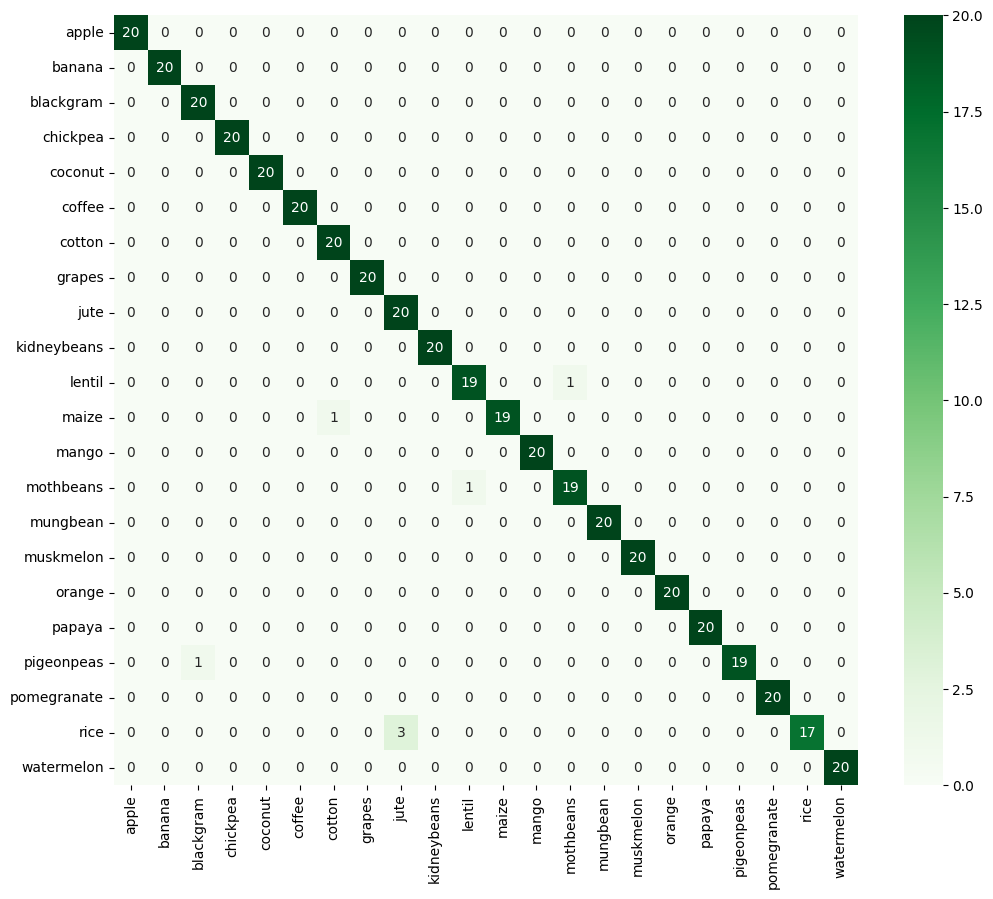

In [11]:
labels=sorted(y.unique()); sns.heatmap(confusion_matrix(yte,pred,labels=labels),annot=True,fmt='d',cmap='Greens',xticklabels=labels,yticklabels=labels); plt.gcf().set_size_inches(12,10); plt.show()

## 6. Error analysis
The cell below compares the model's predictions with the true labels on the held-out test set and lists the most frequent confusions between crops (actual → predicted). Crops with similar soil and climate requirements are the most likely to be confused. Per-crop precision, recall and F1-score are in `reports/classification_report.txt`, and the full confusion matrix is in `reports/figures/09_confusion_matrix.png`.

In [12]:
wrong = Xte.assign(actual=yte, predicted=pred)
wrong = wrong[wrong.actual != wrong.predicted]
print(f"Misclassified: {len(wrong)} of {len(yte)} test samples ({len(wrong)/len(yte):.1%})")
if len(wrong):
    display(wrong.groupby(['actual', 'predicted']).size()
                 .sort_values(ascending=False).head(10)
                 .rename('count').reset_index())
else:
    print("No misclassified samples.")

Misclassified: 7 of 440 test samples (1.6%)


,actual,predicted,count
0,rice,jute,3
1,lentil,mothbeans,1
2,maize,cotton,1
3,mothbeans,lentil,1
4,pigeonpeas,blackgram,1


The full pipeline is saved by `src/train.py` to `models/crop_model.joblib`; the Streamlit app loads it.